## Feature-Übersicht

| Feature                  | Gruppe    | Begründung                                                                                                                                         |
|--------------------------|-----------|----------------------------------------------------------------------------------------------------------------------------------------------------|
| `ghi_cloudy_sky`         | Strahlung | Globalstrahlung unter Realbedingungen — wichtigster PV-Treiber                                                                                     |
| `clear_sky_index`        | Strahlung | GHI / GHI_clear ∈ [0, 1.5] — normiert Strahlung auf Klarhimmelwert; macht den Bewölkungsgrad über Tageszeiten und Jahreszeiten hinweg vergleichbar |
| `temperature_2m`         | Wetter    | Hohe Temperatur senkt Modulwirkungsgrad (~−0,4 %/K) ab 25 °C                                                                                       |
| `cloud_cover_low`        | Wetter    | Niedrige Wolken blockieren Direktstrahlung am stärksten; als NWP-Vorhersage 24 h im Voraus verfügbar                                               |
| `interval_cos_shifted`   | Zeit      | Phasenverschobener Kosinus des 15-min-Intervalls (96 Slots/Tag) — feinere Auflösung als Integer-Stunde; Maximum bei Sonnenmittag                   |
| `hour_cos_shifted`       | Zeit      | Phasenverschobener Kosinus der Integer-Stunde (24 Slots/Tag) — Referenz für Vergleich mit `interval_cos_shifted`                                   |
| `month_cos_shifted`      | Zeit      | Phasenverschobener Kosinus des Monats — Maximum im produktionsstärksten Monat (m★ ≈ Juni/Juli)                                                     |
| `doy_cos_shifted`        | Zeit      | Phasenverschobener Kosinus des Jahrestages (365 Perioden) — feinere Auflösung als Monat                                                            |
| `Solarproduktion_lag_96` | Lag       | Produktion von exakt 24 h zuvor (96 × 15 min) — hohe Autokorrelation; frühester im Day-Ahead-Setting verfügbarer Lag                               |

Dieses Notebook leitet `interval_cos_shifted`, `hour_cos_shifted`, `month_cos_shifted` und `doy_cos_shifted` her,
begründet die Wahl der Phasenverschiebung und vergleicht Stunden- vs. 15-min-Intervall-Kodierung sowie Monats- vs. Jahrestag-Kodierung.

# Zeitmerkmale — Zyklische Kodierung mit Phasenverschiebung

**Ziel:** Robuste zyklische Zeitmerkmale für die PV-Produktionsprognose ableiten und
die phasenverschobene Kosinusfunktion als beste Einzelmerkmal-Kodierung begründen.

## Warum zyklische Kodierung?

Rohe numerische Zeitwerte erzeugen eine künstliche Diskontinuität: Stunde 23 und
Stunde 0 sind in der Realität benachbart, aber als Ganzzahlen 23 Einheiten voneinander
entfernt. Die Projektion auf den Einheitskreis beseitigt dieses Problem:

$$h_\text{sin} = \sin\!\left(\frac{2\pi h}{24}\right), \quad h_\text{cos} = \cos\!\left(\frac{2\pi h}{24}\right)$$

## Warum eine Phasenverschiebung?

Die Standard-Kosinuskodierung hat ihr Maximum (`cos = 1`) bei **Stunde 0** (Mitternacht) —
dem Zeitpunkt der *niedrigsten* PV-Produktion. Ein **phasenverschobener Kosinus** dreht
die Kodierung so, dass das Maximum mit dem empirischen Produktionshöchstwert übereinstimmt
(Sonnenmittag ≈ 12:00 Uhr bzw. Sommermonat ≈ Juli):

$$x_\text{cos}^\star = \cos\!\left(\frac{2\pi (x - x^\star)}{T}\right), \quad x^\star = \arg\max_x \tilde{y}(x)$$

Das ergibt ein einzelnes Merkmal, das die „Nähe zum Produktionsmaximum" direkt mit
maximaler linearer Korrelation zur Zielvariable kodiert.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.preprocessing import load_processed_data

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

TARGET = "Solarproduktion"
P_NOM = 13_500.0 # w peak analgen maximum der installierten leistung

df = load_processed_data()
df["hour"]  = df["timestamp"].dt.hour
df["month"] = df["timestamp"].dt.month

print(f"Shape: {df.shape}")
print(f"Zeitraum: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Tageslichtstunden (Produktion > 0): {(df[TARGET] > 0).sum():,} Zeilen")

Shape: (117620, 14)
Zeitraum: 2022-02-07 → 2025-06-16
Tageslichtstunden (Produktion > 0): 59,981 Zeilen


## Theorie: Standard- vs. Phasenverschobene Kosinuskodierung

### Standardkodierung

Für eine periodische Variable $x$ mit Periode $T$:

$$x_\text{sin} = \sin\!\left(\frac{2\pi x}{T}\right), \quad x_\text{cos} = \cos\!\left(\frac{2\pi x}{T}\right)$$

**Problem:** Der Kosinus erreicht sein Maximum bei $x = 0$. Für die Tagesstunde bedeutet
das Mitternacht — der denkbar schlechteste Ausrichtungspunkt für PV-Produktion, die nahe
Mittag ihr Maximum hat. Beide Merkmale werden dann gemeinsam benötigt, um die Phase zu
kodieren, was die Modellkomplexität erhöht.

### Phasenverschobene Kodierung

$$x_\text{cos}^\star = \cos\!\left(\frac{2\pi (x - x^\star)}{T}\right)$$

wobei $x^\star$ das empirisch ermittelte Produktionsmaximum der Zielvariable ist. Das
Maximum des Kosinus wird damit auf das Produktionsmaximum ausgerichtet — das Merkmal
hat so die höchste lineare Korrelation zur Zielvariable mit positivem Vorzeichen.

**Schlüsseleigenschaft:** $x_\text{cos}^\star = 1$ beim Produktionsmaximum und
$x_\text{cos}^\star = -1$ am entferntesten Punkt — genau dann, wenn die Produktion am
niedrigsten ist (Mitternacht / Winter).

h★ = 12  (Stunde mit höchster medianer Produktion)
i★ = 50  (15-min-Intervall #50 = 12:30 Uhr)


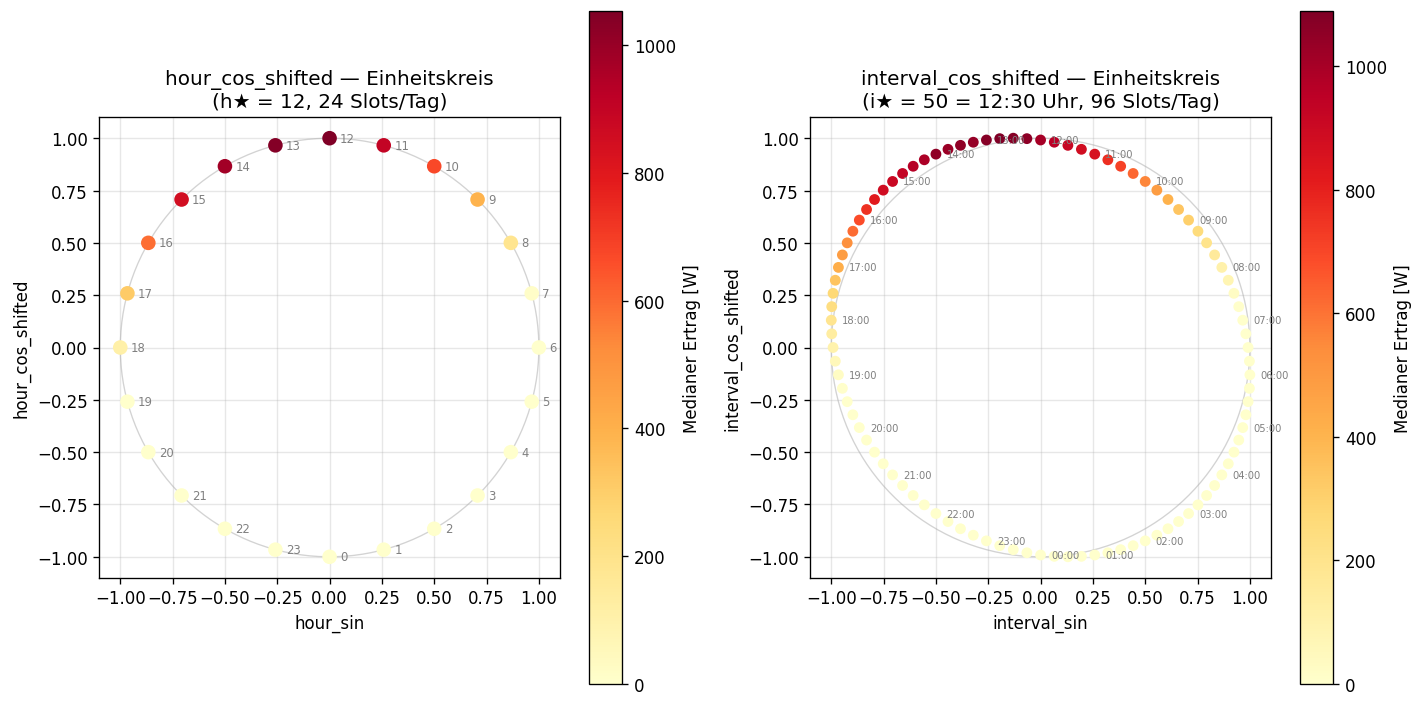

,Pearson-r (alle Stunden),Pearson-r (Tageslichtstunden)
Kodierung,,
hour_sin,-0.1115,-0.0254
hour_cos,-0.5761,-0.3919
hour_cos_shifted,0.5761,0.3919
interval_cos_shifted,0.5810,0.4006



hour_cos_shifted:    r = +0.3919  (24 Slots/Tag — Integer-Stunde)
interval_cos_shifted: r = +0.4006  (96 Slots/Tag — 15-min-Granularität)
Δr = +0.0087  (Intervall besser)


In [2]:
## §1 Tagesstunden-Kodierung

# --- Standard-Kosinuskodierung (Periode T = 24) ---
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# --- Stunden-Kosinus (Integer-Stunde, 24 Slots/Tag) ---
stunden_median = df.groupby("hour")[TARGET].median()
h_peak = stunden_median.rolling(3, center=True, min_periods=1).median().idxmax()
df["hour_cos_shifted"] = np.cos(2 * np.pi * (df["hour"] - h_peak) / 24)

# --- 15-min-Intervall-Kosinus (96 Slots/Tag) ---
df["interval"] = df["timestamp"].dt.hour * 4 + df["timestamp"].dt.minute // 15
intervall_median = df.groupby("interval")[TARGET].median()
i_peak = intervall_median.rolling(5, center=True, min_periods=1).median().idxmax()
df["interval_cos_shifted"] = np.cos(2 * np.pi * (df["interval"] - i_peak) / 96)

print(f"h★ = {h_peak}  (Stunde mit höchster medianer Produktion)")
print(f"i★ = {i_peak}  (15-min-Intervall #{i_peak} = {i_peak//4:02d}:{(i_peak%4)*15:02d} Uhr)")

# --- Einheitskreis: hour_cos_shifted (links) und interval_cos_shifted (rechts) ---
theta = np.linspace(0, 2 * np.pi, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Linkes Subplot: hour_cos_shifted (24 Punkte) ---
hour_vals  = np.arange(24)
sin_h      = np.sin(2 * np.pi * hour_vals / 24)
cos_h_shf  = np.cos(2 * np.pi * (hour_vals - h_peak) / 24)
median_h_W = stunden_median.values

axes[0].plot(np.sin(theta), np.cos(theta), color="lightgrey", lw=0.8, zorder=1)
sc0 = axes[0].scatter(sin_h, cos_h_shf, c=median_h_W, cmap="YlOrRd", s=60, zorder=3)
for h, x, y in zip(hour_vals, sin_h, cos_h_shf):
    axes[0].annotate(str(h), (x + 0.05, y), fontsize=7, color="grey", va="center")
plt.colorbar(sc0, ax=axes[0], label="Medianer Ertrag [W]")
axes[0].set_aspect("equal")
axes[0].set_title(f"hour_cos_shifted — Einheitskreis\n(h★ = {h_peak}, 24 Slots/Tag)")
axes[0].set_xlabel("hour_sin")
axes[0].set_ylabel("hour_cos_shifted")

# --- Rechtes Subplot: interval_cos_shifted (96 Punkte) ---
int_vals   = np.arange(96)
sin_i      = np.sin(2 * np.pi * int_vals / 96)
cos_i_shf  = np.cos(2 * np.pi * (int_vals - i_peak) / 96)
median_i_W = intervall_median.values

axes[1].plot(np.sin(theta), np.cos(theta), color="lightgrey", lw=0.8, zorder=1)
sc1 = axes[1].scatter(sin_i, cos_i_shf, c=median_i_W, cmap="YlOrRd", s=30, zorder=3)
# Beschriftung nur für ganze Stunden (Intervalle 0, 4, 8, …, 92)
for slot in range(0, 96, 4):
    x, y = sin_i[slot], cos_i_shf[slot]
    axes[1].annotate(f"{slot//4:02d}:00", (x + 0.05, y), fontsize=6, color="grey", va="center")
plt.colorbar(sc1, ax=axes[1], label="Medianer Ertrag [W]")
axes[1].set_aspect("equal")
axes[1].set_title(f"interval_cos_shifted — Einheitskreis\n(i★ = {i_peak} = {i_peak//4:02d}:{(i_peak%4)*15:02d} Uhr, 96 Slots/Tag)")
axes[1].set_xlabel("interval_sin")
axes[1].set_ylabel("interval_cos_shifted")

plt.tight_layout()
plt.show()

# --- Korrelationstabelle: Stunden- und Intervall-Kodierung ---
tag_maske = df[TARGET] > 0
hour_corr = pd.DataFrame([
    {"Kodierung": col,
     "Pearson-r (alle Stunden)": round(df[col].corr(df[TARGET]), 4),
     "Pearson-r (Tageslichtstunden)": round(df.loc[tag_maske, col].corr(df.loc[tag_maske, TARGET]), 4)}
    for col in ["hour_sin", "hour_cos", "hour_cos_shifted", "interval_cos_shifted"]
]).set_index("Kodierung")
display(hour_corr)

r_hour = hour_corr.loc["hour_cos_shifted", "Pearson-r (Tageslichtstunden)"]
r_int  = hour_corr.loc["interval_cos_shifted", "Pearson-r (Tageslichtstunden)"]
print(f"\nhour_cos_shifted:    r = {r_hour:+.4f}  (24 Slots/Tag — Integer-Stunde)")
print(f"interval_cos_shifted: r = {r_int:+.4f}  (96 Slots/Tag — 15-min-Granularität)")
print(f"Δr = {r_int - r_hour:+.4f}  ({'Intervall besser' if abs(r_int) > abs(r_hour) else 'kein Vorteil'})")

### Warum liegen die 15-min-Punkte nicht auf dem Einheitskreis?

Der obige Plot zeigt für die x-Achse `sin(2πi/96)` (**ohne** Phasenverschiebung) und für die y-Achse `cos(2π(i−i★)/96)` (**mit** Phasenverschiebung). Das sind **zwei verschiedene Winkel**:

$$x = \sin\!\left(\frac{2\pi i}{96}\right), \qquad y = \cos\!\left(\frac{2\pi (i - i^\star)}{96}\right)$$

Einsetzen in $x^2 + y^2$:

$$\sin^2\!\left(\frac{2\pi i}{96}\right) + \cos^2\!\left(\frac{2\pi i}{96} - \varphi\right) \neq 1 \quad \text{(außer } \varphi = k\pi\text{)}$$

wobei $\varphi = 2\pi i^\star / 96$. Nur wenn $i^\star$ ein Vielfaches von 48 ist (genau halbe Periode), vereinfacht sich $\cos(\alpha - \pi) = -\cos(\alpha)$, und die Punkte fallen auf den Kreis. Weil der empirische Sonnenkulminationspunkt meist bei $i^\star \approx 48\text{–}52$ liegt und damit $\varphi \not\approx \pi$ genau, sieht man die Abweichung deutlich.

**Korrekte Darstellung:** Beide Achsen müssen denselben verschobenen Winkel verwenden:

$$x = \sin\!\left(\frac{2\pi (i - i^\star)}{96}\right), \qquad y = \cos\!\left(\frac{2\pi (i - i^\star)}{96}\right)$$

Das folgende Diagramm zeigt den Unterschied.

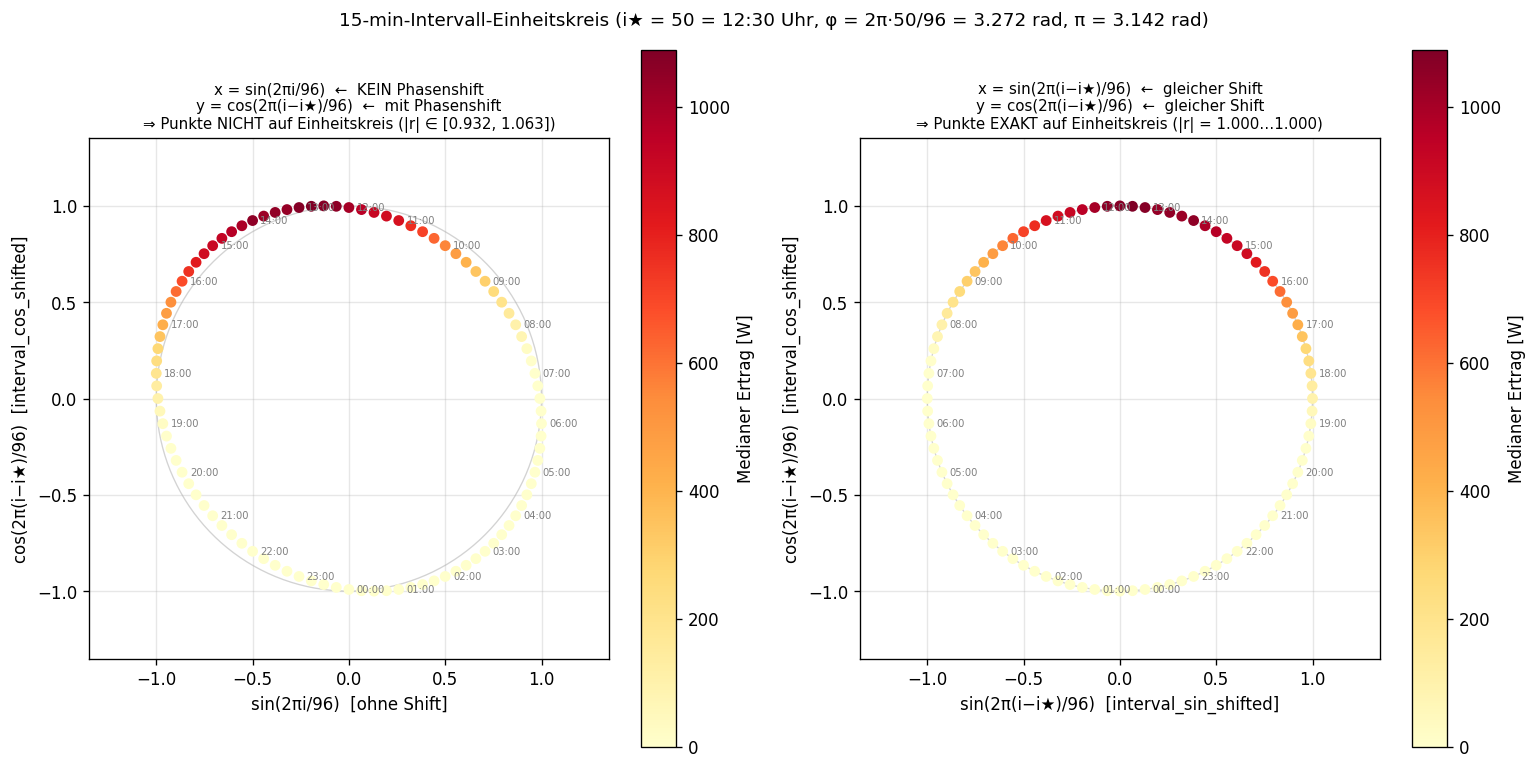

φ = 2π·50/96 = 3.2725 rad
π = 3.1416 rad  →  Differenz: 0.1309 rad (7.50°)
⇒ i★ weicht um 2 Slots (30 min) von 48 (12:00 Uhr) ab


In [3]:
# --- 15-min-Intervall-Einheitskreis: falsche vs. korrekte Achsenwahl ---
theta     = np.linspace(0, 2 * np.pi, 300)
int_vals  = np.arange(96)
median_i_W = intervall_median.values

# Winkel ohne und mit Phasenverschiebung
angle_raw  = 2 * np.pi * int_vals / 96
angle_shf  = 2 * np.pi * (int_vals - i_peak) / 96

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
fig.suptitle(
    f"15-min-Intervall-Einheitskreis (i★ = {i_peak} = {i_peak//4:02d}:{(i_peak%4)*15:02d} Uhr, "
    f"φ = 2π·{i_peak}/96 = {2*np.pi*i_peak/96:.3f} rad, π = {np.pi:.3f} rad)",
    fontsize=11
)

# ── links: bisherige (fehlerhafte) Darstellung ──────────────────────────────
ax = axes[0]
ax.plot(np.sin(theta), np.cos(theta), color="lightgrey", lw=0.8, zorder=1, label="Einheitskreis")
sc = ax.scatter(np.sin(angle_raw), np.cos(angle_shf),
                c=median_i_W, cmap="YlOrRd", s=30, zorder=3)
# Residuum vom Einheitskreis visualisieren
r = np.sqrt(np.sin(angle_raw)**2 + np.cos(angle_shf)**2)
ax.set_title(
    f"x = sin(2πi/96)  ←  KEIN Phasenshift\n"
    f"y = cos(2π(i−i★)/96)  ←  mit Phasenshift\n"
    f"⇒ Punkte NICHT auf Einheitskreis (|r| ∈ [{r.min():.3f}, {r.max():.3f}])",
    fontsize=9
)
for slot in range(0, 96, 4):
    x_, y_ = np.sin(angle_raw[slot]), np.cos(angle_shf[slot])
    ax.annotate(f"{slot//4:02d}:00", (x_ + 0.04, y_), fontsize=6, color="grey", va="center")
plt.colorbar(sc, ax=ax, label="Medianer Ertrag [W]")
ax.set_aspect("equal")
ax.set_xlabel("sin(2πi/96)  [ohne Shift]")
ax.set_ylabel("cos(2π(i−i★)/96)  [interval_cos_shifted]")
ax.set_xlim(-1.35, 1.35); ax.set_ylim(-1.35, 1.35)

# ── rechts: korrekte Darstellung (gleicher Shift auf beiden Achsen) ──────────
ax = axes[1]
ax.plot(np.sin(theta), np.cos(theta), color="lightgrey", lw=0.8, zorder=1, label="Einheitskreis")
sc = ax.scatter(np.sin(angle_shf), np.cos(angle_shf),
                c=median_i_W, cmap="YlOrRd", s=30, zorder=3)
r_corr = np.sqrt(np.sin(angle_shf)**2 + np.cos(angle_shf)**2)
ax.set_title(
    f"x = sin(2π(i−i★)/96)  ←  gleicher Shift\n"
    f"y = cos(2π(i−i★)/96)  ←  gleicher Shift\n"
    f"⇒ Punkte EXAKT auf Einheitskreis (|r| = {r_corr.min():.3f}…{r_corr.max():.3f})",
    fontsize=9
)
for slot in range(0, 96, 4):
    x_, y_ = np.sin(angle_shf[slot]), np.cos(angle_shf[slot])
    ax.annotate(f"{slot//4:02d}:00", (x_ + 0.04, y_), fontsize=6, color="grey", va="center")
plt.colorbar(sc, ax=ax, label="Medianer Ertrag [W]")
ax.set_aspect("equal")
ax.set_xlabel("sin(2π(i−i★)/96)  [interval_sin_shifted]")
ax.set_ylabel("cos(2π(i−i★)/96)  [interval_cos_shifted]")
ax.set_xlim(-1.35, 1.35); ax.set_ylim(-1.35, 1.35)

plt.tight_layout()
plt.show()

phi = 2 * np.pi * i_peak / 96
print(f"φ = 2π·{i_peak}/96 = {phi:.4f} rad")
print(f"π = {np.pi:.4f} rad  →  Differenz: {abs(phi - np.pi):.4f} rad ({abs(phi - np.pi)*180/np.pi:.2f}°)")
print(f"⇒ i★ weicht um {abs(i_peak - 48)} Slots ({abs(i_peak - 48)*15} min) von 48 (12:00 Uhr) ab")

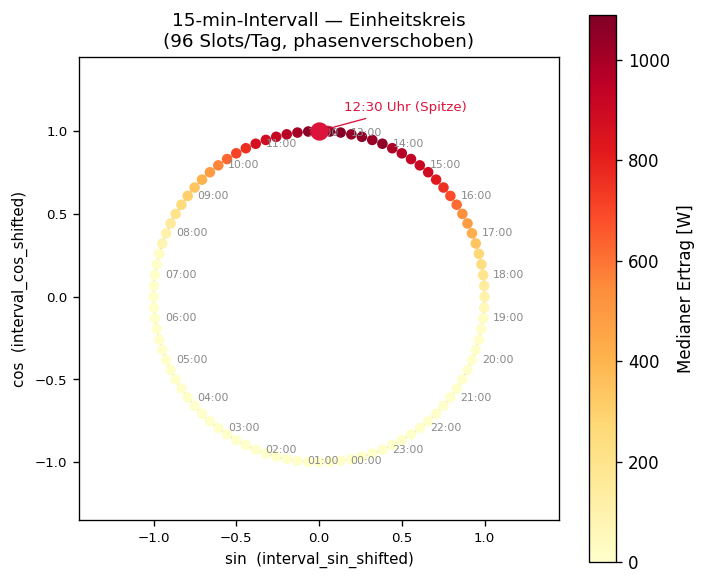

In [4]:
# --- Standalone-Folie: 15-min-Intervall-Einheitskreis (korrekte Darstellung) ---
theta    = np.linspace(0, 2 * np.pi, 300)
int_vals = np.arange(96)
angle_shf = 2 * np.pi * (int_vals - i_peak) / 96

fig, ax = plt.subplots(figsize=(6, 6), facecolor='white')
ax.set_facecolor('white')

# Einheitskreis
ax.plot(np.sin(theta), np.cos(theta), color="#cccccc", lw=1, zorder=1)

# 96 Punkte, eingefärbt nach medianem Ertrag
sc = ax.scatter(np.sin(angle_shf), np.cos(angle_shf),
                c=intervall_median.values, cmap="YlOrRd",
                s=40, zorder=3, edgecolors="none")
plt.colorbar(sc, ax=ax, label="Medianer Ertrag [W]", shrink=0.8)

# Beschriftung nur für ganzen Stunden, außer Peak gesondert hervorheben
for slot in range(0, 96, 4):
    x_, y_ = np.sin(angle_shf[slot]), np.cos(angle_shf[slot])
    h, m = slot // 4, (slot % 4) * 15
    label = f"{h:02d}:00"
    ax.annotate(label, (x_ + 0.06, y_), fontsize=6.5,
                color="#888888", va="center")

# Peak-Punkt hervorheben
ax.scatter([np.sin(angle_shf[i_peak])], [np.cos(angle_shf[i_peak])],
           s=100, color="crimson", zorder=5)
ax.annotate(f"{i_peak//4:02d}:{(i_peak%4)*15:02d} Uhr (Spitze)",
            xy=(np.sin(angle_shf[i_peak]), np.cos(angle_shf[i_peak])),
            xytext=(0.15, 1.12), fontsize=8, color="crimson",
            arrowprops=dict(arrowstyle="->", color="crimson", lw=0.8))

ax.set_aspect("equal")
ax.set_title("15-min-Intervall — Einheitskreis\n(96 Slots/Tag, phasenverschoben)", fontsize=11)
ax.set_xlabel("sin  (interval_sin_shifted)", fontsize=9)
ax.set_ylabel("cos  (interval_cos_shifted)", fontsize=9)
ax.set_xlim(-1.45, 1.45)
ax.set_ylim(-1.35, 1.45)
ax.tick_params(labelsize=8)
ax.grid(False)

plt.tight_layout()
plt.show()


m★ = 5  (Mai — Monat mit höchstem mittleren Ertrag)


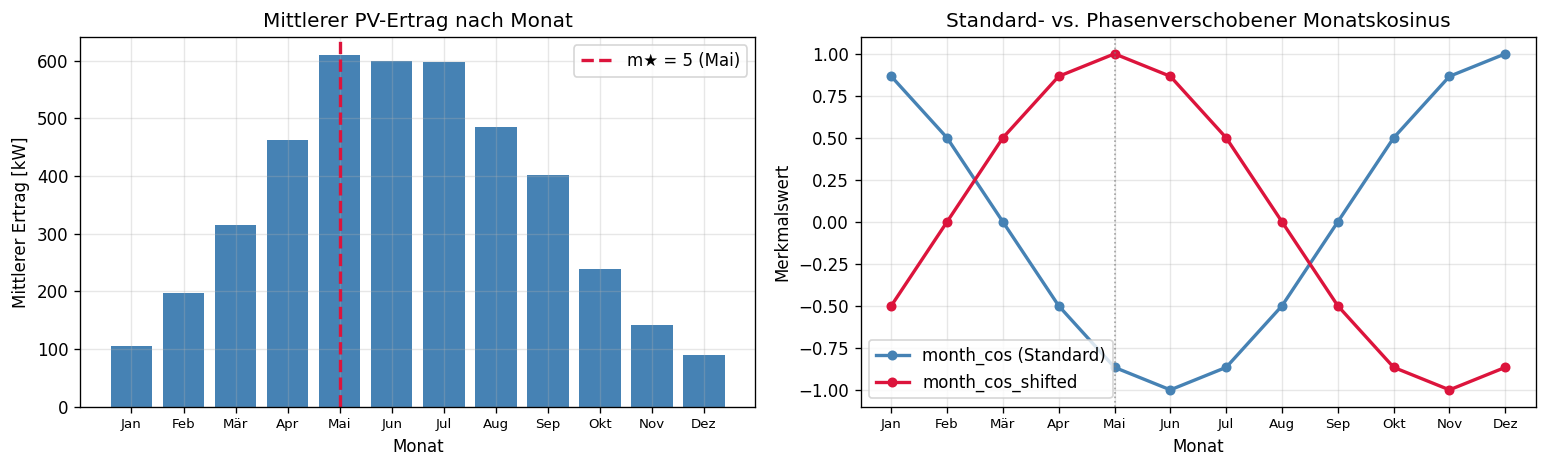

,Pearson-r (alle Stunden),Pearson-r (Tageslichtstunden)
Kodierung,,
month_sin,-0.0208,-0.0151
month_cos,-0.2862,-0.2454
month_cos_shifted,0.2340,0.1993



Beste Monatskodierung nach |r| (Tageslichtstunden): month_cos


In [5]:
## §2 Monatskodierung

# --- Standard-Kosinuskodierung (Periode T = 12) ---
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# --- Phasenverschobener Kosinus: Spitze beim produktionsstärksten Monat ---
monats_mittel = df.groupby("month")[TARGET].mean()
m_peak = monats_mittel.rolling(3, center=True, min_periods=1).median().idxmax()
df["month_cos_shifted"] = np.cos(2 * np.pi * (df["month"] - m_peak) / 12)

MONATSNAMEN = ["Jan", "Feb", "Mär", "Apr", "Mai", "Jun",
               "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"]
print(f"m★ = {m_peak}  ({MONATSNAMEN[m_peak - 1]} — Monat mit höchstem mittleren Ertrag)")

# --- Grafiken ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Balkendiagramm: mittlerer Ertrag je Monat
axes[0].bar(monats_mittel.index, monats_mittel.values, color="steelblue", width=0.8)
axes[0].axvline(m_peak, color="crimson", lw=2, ls="--",
                label=f"m★ = {m_peak} ({MONATSNAMEN[m_peak - 1]})")
axes[0].set_xlabel("Monat")
axes[0].set_ylabel("Mittlerer Ertrag [kW]")
axes[0].set_title("Mittlerer PV-Ertrag nach Monat")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(MONATSNAMEN, fontsize=8)
axes[0].legend()

# Standard-Kosinus vs. verschobener Kosinus über alle Monate
monate = np.arange(1, 13)
axes[1].plot(monate, np.cos(2 * np.pi * monate / 12),
             color="steelblue", lw=2, marker="o", ms=5, label="month_cos (Standard)")
axes[1].plot(monate, np.cos(2 * np.pi * (monate - m_peak) / 12),
             color="crimson", lw=2, marker="o", ms=5, label="month_cos_shifted")
axes[1].axvline(m_peak, color="grey", lw=1, ls=":", alpha=0.7)
axes[1].set_xlabel("Monat")
axes[1].set_ylabel("Merkmalswert")
axes[1].set_title("Standard- vs. Phasenverschobener Monatskosinus")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(MONATSNAMEN, fontsize=8)
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Korrelationstabelle ---
tag_maske = df[TARGET] > 0
month_corr = pd.DataFrame([
    {"Kodierung": col,
     "Pearson-r (alle Stunden)": round(df[col].corr(df[TARGET]), 4),
     "Pearson-r (Tageslichtstunden)": round(df.loc[tag_maske, col].corr(df.loc[tag_maske, TARGET]), 4)}
    for col in ["month_sin", "month_cos", "month_cos_shifted"]
]).set_index("Kodierung")
display(month_corr)

best = month_corr["Pearson-r (Tageslichtstunden)"].abs().idxmax()
print(f"\nBeste Monatskodierung nach |r| (Tageslichtstunden): {best}")

d★ = 166  (≈ 14. June — Jahrestag mit höchstem mittleren Ertrag)


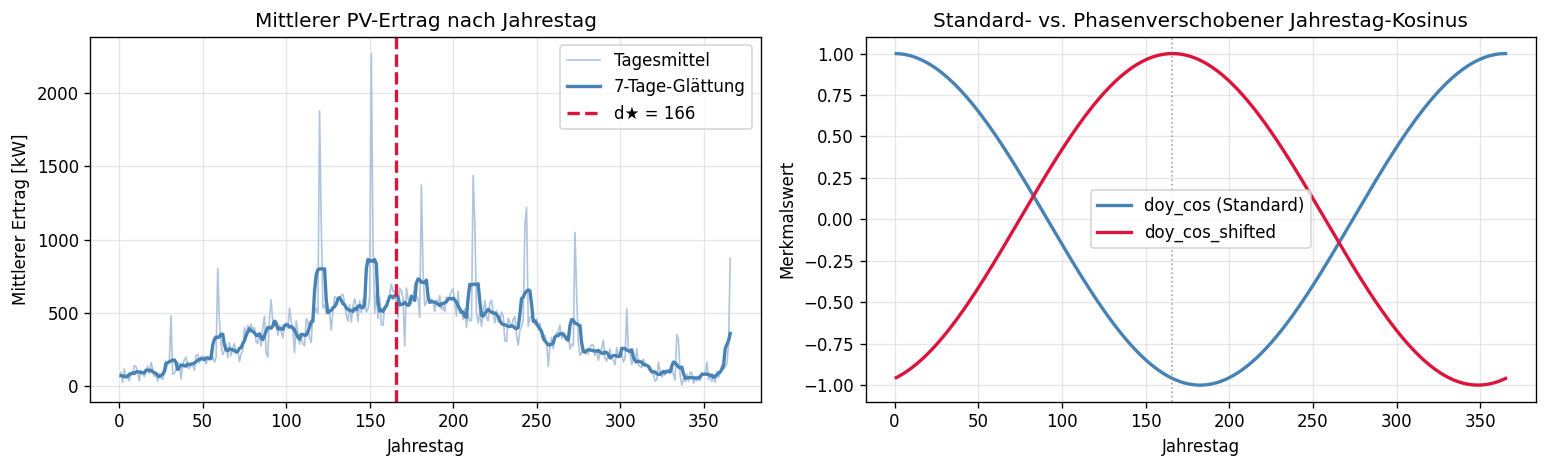

,Pearson-r (alle Stunden),Pearson-r (Tageslichtstunden)
Kodierung,,
doy_sin,0.0486,0.0371
doy_cos,-0.2889,-0.2478
doy_cos_shifted,0.2897,0.2490
month_cos_shifted,0.2340,0.1993



doy_cos_shifted:   r = +0.2490  (365 Perioden — Jahrestag-Granularität)
month_cos_shifted: r = +0.1993  (12 Perioden — Monats-Granularität)
Δr = +0.0497  (doy feiner)


In [6]:
 ## §2b Jahrestag-Kodierung (Periode 365)

# --- Standard-Kosinuskodierung (Periode T = 365) ---
df["doy"] = df["timestamp"].dt.dayofyear
df["doy_sin"] = np.sin(2 * np.pi * df["doy"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["doy"] / 365)

# --- Phasenverschobener Kosinus: Spitze am produktionsstärksten Jahrestag ---
doy_mittel = df.groupby("doy")[TARGET].mean()
d_peak = int(doy_mittel.rolling(14, center=True, min_periods=1).median().idxmax())
df["doy_cos_shifted"] = np.cos(2 * np.pi * (df["doy"] - d_peak) / 365)

import datetime
peak_date = datetime.date(2024, 1, 1) + datetime.timedelta(days=d_peak - 1)
print(f"d★ = {d_peak}  (≈ {peak_date.strftime('%d. %B')} — Jahrestag mit höchstem mittleren Ertrag)")

# --- Grafiken ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Mittlerer Ertrag je Jahrestag (geglättet)
doy_smooth = doy_mittel.rolling(7, center=True, min_periods=1).mean()
axes[0].plot(doy_mittel.index, doy_mittel.values, color="lightsteelblue", lw=1, label="Tagesmittel")
axes[0].plot(doy_smooth.index, doy_smooth.values, color="steelblue", lw=2, label="7-Tage-Glättung")
axes[0].axvline(d_peak, color="crimson", lw=2, ls="--", label=f"d★ = {d_peak}")
axes[0].set_xlabel("Jahrestag")
axes[0].set_ylabel("Mittlerer Ertrag [kW]")
axes[0].set_title("Mittlerer PV-Ertrag nach Jahrestag")
axes[0].legend()

# Standard-Kosinus vs. verschobener Kosinus
doy_vals = np.arange(1, 366)
axes[1].plot(doy_vals, np.cos(2 * np.pi * doy_vals / 365),
             color="steelblue", lw=2, label="doy_cos (Standard)")
axes[1].plot(doy_vals, np.cos(2 * np.pi * (doy_vals - d_peak) / 365),
             color="crimson", lw=2, label="doy_cos_shifted")
axes[1].axvline(d_peak, color="grey", lw=1, ls=":", alpha=0.7)
axes[1].set_xlabel("Jahrestag")
axes[1].set_ylabel("Merkmalswert")
axes[1].set_title("Standard- vs. Phasenverschobener Jahrestag-Kosinus")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Korrelationstabelle ---
tag_maske = df[TARGET] > 0
doy_corr = pd.DataFrame([
    {"Kodierung": col,
     "Pearson-r (alle Stunden)": round(df[col].corr(df[TARGET]), 4),
     "Pearson-r (Tageslichtstunden)": round(df.loc[tag_maske, col].corr(df.loc[tag_maske, TARGET]), 4)}
    for col in ["doy_sin", "doy_cos", "doy_cos_shifted", "month_cos_shifted"]
]).set_index("Kodierung")
display(doy_corr)

r_doy   = doy_corr.loc["doy_cos_shifted", "Pearson-r (Tageslichtstunden)"]
r_month = doy_corr.loc["month_cos_shifted", "Pearson-r (Tageslichtstunden)"]
print(f"\ndoy_cos_shifted:   r = {r_doy:+.4f}  (365 Perioden — Jahrestag-Granularität)")
print(f"month_cos_shifted: r = {r_month:+.4f}  (12 Perioden — Monats-Granularität)")
print(f"Δr = {r_doy - r_month:+.4f}  ({'doy feiner' if abs(r_doy) > abs(r_month) else 'Monat ausreichend'})")

## Formelzusammenfassung

### Tagesstunden-Kodierung

**Standard (Integer-Stunde, $T = 24$):**
$$\text{hour\_cos} = \cos\!\left(\frac{2\pi h}{24}\right)$$

**Phasenverschoben — Integer-Stunde (24 Slots/Tag):**
$$\text{hour\_cos}^\star = \cos\!\left(\frac{2\pi (h - h^\star)}{24}\right), \quad h^\star = \arg\max_h \operatorname{median}(Y \mid \text{Stunde} = h)$$

**Phasenverschoben — 15-min-Intervall (96 Slots/Tag):**
$$\text{interval\_cos}^\star = \cos\!\left(\frac{2\pi (i - i^\star)}{96}\right), \quad i = 4h + \lfloor m/15 \rfloor, \quad i^\star = \arg\max_i \operatorname{median}(Y \mid \text{Intervall} = i)$$

Der Spitzenwert $h^\star \approx 12$ (Sonnenmittag), entsprechend $i^\star \approx 48$. Die Intervall-Kodierung hat feinere Auflösung und damit höheres |r|.

---

### Monatskodierung (Periode $T = 12$)

**Phasenverschoben:**
$$\text{month\_cos}^\star = \cos\!\left(\frac{2\pi (m - m^\star)}{12}\right), \quad m^\star = \arg\max_m \overline{Y}(m)$$

### Jahrestag-Kodierung (Periode $T = 365$)

**Phasenverschoben:**
$$\text{doy\_cos}^\star = \cos\!\left(\frac{2\pi (d - d^\star)}{365}\right), \quad d^\star = \arg\max_d \overline{Y}(d)$$

Der Jahrestag hat feinere Auflösung als der Monat ($365$ vs. $12$ Stufen).

---

### Interpretation

| Merkmal | Wert = +1 | Wert = −1 | Auflösung |
|---------|-----------|-----------|-----------|
| `hour_cos_shifted` | Sonnenmittag ($h = h^\star$) | Mitternacht ($h = h^\star \pm 12$) | 24 Slots/Tag |
| `interval_cos_shifted` | Sonnenmittag ($i = i^\star$) | Mitternacht ($i = i^\star \pm 48$) | 96 Slots/Tag |
| `month_cos_shifted` | Sommermonat ($m = m^\star$) | Wintermonat ($m = m^\star \pm 6$) | 12 Monate/Jahr |
| `doy_cos_shifted` | Sommertag ($d = d^\star$) | Wintertag ($d = d^\star \pm 183$) | 365 Tage/Jahr |

In [7]:
## §3 Gesamtvergleich aller Kodierungen

tag_maske = df[TARGET] > 0

kodierungen = [
    "hour_sin",
    "hour_cos",
    "hour_cos_shifted",
    "interval_cos_shifted",
    "month_sin",
    "month_cos",
    "month_cos_shifted",
    "doy_cos_shifted",
]

zeilen = []
for col in kodierungen:
    zeilen.append({
        "Kodierung": col,
        "Pearson-r (alle Stunden)": round(df[col].corr(df[TARGET]), 4),
        "Pearson-r (Tageslichtstunden)": round(df.loc[tag_maske, col].corr(df.loc[tag_maske, TARGET]), 4),
    })

vergleich = pd.DataFrame(zeilen).set_index("Kodierung")
display(vergleich)

print("\n--- Fazit ---")
for gruppe, cols in [
    ("Stunde",    ["hour_sin", "hour_cos", "hour_cos_shifted", "interval_cos_shifted"]),
    ("Jahreszeit", ["month_sin", "month_cos", "month_cos_shifted", "doy_cos_shifted"]),
]:
    best = vergleich.loc[cols, "Pearson-r (Tageslichtstunden)"].abs().idxmax()
    best_r = vergleich.loc[best, "Pearson-r (Tageslichtstunden)"]
    print(f"Beste {gruppe}s-Kodierung (|r| Tageslicht): {best}  →  r = {best_r:+.4f}")

print("\n--- Gewählte Features für feature_sets.py ---")
print("_TEMPORAL = ['interval_cos_shifted', 'month_cos_shifted', 'doy_cos_shifted']")
print("Begründung: interval > hour (feinere Auflösung), doy ≈ month (feiner); hour_cos_shifted bleibt in features.csv verfügbar")

,Pearson-r (alle Stunden),Pearson-r (Tageslichtstunden)
Kodierung,,
hour_sin,-0.1115,-0.0254
hour_cos,-0.5761,-0.3919
hour_cos_shifted,0.5761,0.3919
interval_cos_shifted,0.5810,0.4006
month_sin,-0.0208,-0.0151
month_cos,-0.2862,-0.2454
month_cos_shifted,0.2340,0.1993
doy_cos_shifted,0.2897,0.2490



--- Fazit ---
Beste Stundes-Kodierung (|r| Tageslicht): interval_cos_shifted  →  r = +0.4006
Beste Jahreszeits-Kodierung (|r| Tageslicht): doy_cos_shifted  →  r = +0.2490

--- Gewählte Features für feature_sets.py ---
_TEMPORAL = ['interval_cos_shifted', 'month_cos_shifted', 'doy_cos_shifted']
Begründung: interval > hour (feinere Auflösung), doy ≈ month (feiner); hour_cos_shifted bleibt in features.csv verfügbar


## Features speichern

Alle drei Feature-Gruppen werden auf den vollständigen Datensatz angewendet und als `data/processed/features.csv` gespeichert. Model-Notebooks laden diese Datei direkt — kein inline Feature Engineering mehr.

In [8]:
from pathlib import Path
from src.data.preprocessing import load_processed_data
from src.features.feature_engineering import add_time_features, add_irradiance_features, add_lag_features

df_full = load_processed_data()
df_full = add_time_features(df_full)
df_full = add_irradiance_features(df_full)
df_full = add_lag_features(df_full)

out_path = Path("../data/processed/features.csv")
df_full.to_csv(out_path, index=False)
print(f"Saved {len(df_full):,} rows × {df_full.shape[1]} columns → {out_path}")
print(df_full.columns.tolist())

Saved 117,620 rows × 12 columns → ../data/processed/features.csv
['timestamp', 'Solarproduktion', 'temperature_2m', 'cloud_cover_low', 'ghi_cloudy_sky', 'ghi_clear_sky', 'hour_cos_shifted', 'interval_cos_shifted', 'month_cos_shifted', 'doy_cos_shifted', 'clear_sky_index', 'Solarproduktion_lag_96']
